<a href="https://colab.research.google.com/github/raghavrakesh20/Small-projects-excersises./blob/main/Image_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# STEP 1: Configuration and Imports
import os
import glob
import json
import vertexai
from vertexai.generative_models import GenerativeModel, Part, Image

# Project configuration
JSON_FILE_PATH = '/content/renaissance-ocr-4aabe5b8dc65 (1).json'
PROJECT_ID = 'renaissance-ocr'
LOCATION = 'global'
GEMINI_MODEL = 'gemini-3.1-pro-preview'

print("Step 1 Complete: Environment configured.")

Step 1 Complete: Environment configured.


In [21]:
# STEP 2: Vertex AI Authentication and Initialization
try:
    os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = JSON_FILE_PATH
    vertexai.init(project=PROJECT_ID, location=LOCATION)
    model = GenerativeModel(GEMINI_MODEL)
    print(f"Step 2 Complete: Gemini Model '{GEMINI_MODEL}' initialized successfully.")
except Exception as e:
    print(f"Step 2 Failed: {e}")

Step 2 Complete: Gemini Model 'gemini-3.1-pro-preview' initialized successfully.


/usr/local/lib/python3.12/dist-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [22]:
# STEP 3: Define Cultural Analysis Function
def analyze_cultural_performance(image_path):
    """
    Acts as a Digital Humanity Expert to annotate the Siddi Goma-Dhamal.
    """
    with open(image_path, 'rb') as f:
        image_bytes = f.read()

    visual_context = Image.from_bytes(image_bytes)

    prompt = """
    Analyze this image of a Siddi Goma-Dhamal performance.
    1. Annotate 'visual messages' (attire, instruments, and movement).
    2. Identify 'African-Indian synthesis' within the frame.
    3. Provide a digital art historian perspective on composition and narrative.
    """

    response = model.generate_content([prompt, visual_context])
    return response.text

print("Step 3 Complete: Analysis function defined.")

Step 3 Complete: Analysis function defined.


In [23]:
# STEP 4: Batch Process Images and Save Results
image_files = glob.glob('/content/*.JPG') + glob.glob('/content/*.jpg')
all_results = []

print(f"Step 4: Starting analysis for {len(image_files)} images...")

for path in image_files:
    try:
        analysis_text = analyze_cultural_performance(path)
        all_results.append({
            "image_id": os.path.basename(path),
            "analysis": analysis_text,
            "category": "Siddi Goma-Dhamal Performance"
        })
        print(f" - Successfully processed: {os.path.basename(path)}")
    except Exception as e:
        print(f" - Error processing {path}: {e}")

# Save to JSON
with open('cultural_analytics_results.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("\nStep 4 Complete: All data saved to 'cultural_analytics_results.json'.")

Step 4: Starting analysis for 4 images...
 - Successfully processed: IMG_0459.JPG
 - Successfully processed: IMG_0479.JPG
 - Successfully processed: IMG_0490.JPG
 - Successfully processed: IMG_0481.JPG

Step 4 Complete: All data saved to 'cultural_analytics_results.json'.


# Task
Load the analysis results from "cultural_analytics_results.json" into a pandas DataFrame and create a visual display or table that presents the Image ID alongside the full cultural analysis text to summarize the batch processing of the Siddi Goma-Dhamal performance images.

## Load Analysis Results

### Subtask:
Read the 'cultural_analytics_results.json' file into a pandas DataFrame.


**Reasoning**:
Load the cultural analysis results into a pandas DataFrame to prepare for further processing or visualization.



In [24]:
import pandas as pd

# Load the analysis results into a DataFrame
df_results = pd.read_json('cultural_analytics_results.json')

# Display the first few rows to verify the data
print("DataFrame loaded successfully. Shape:", df_results.shape)
display(df_results.head())

DataFrame loaded successfully. Shape: (4, 3)


,image_id,analysis,category
0,IMG_0459.JPG,Based on the visual evidence in the photograph...,Siddi Goma-Dhamal Performance
1,IMG_0479.JPG,Based on the visual evidence in the photograph...,Siddi Goma-Dhamal Performance
2,IMG_0490.JPG,"Based on the visual evidence in the image, her...",Siddi Goma-Dhamal Performance
3,IMG_0481.JPG,Based on the visual evidence in the photograph...,Siddi Goma-Dhamal Performance


## Create Visual Display

### Subtask:
Generate a clean visual layout or table that shows the Image ID alongside its full cultural analysis text for easy review.


**Reasoning**:
I will create a clean visual display by iterating through the DataFrame and rendering each analysis result as a formatted HTML block to ensure readability and prevent text truncation.



In [25]:
from IPython.display import HTML, display

# Iterate through the DataFrame to display results in a clean HTML format
for index, row in df_results.iterrows():
    html_content = f"""
    <div style='border: 1px solid #ddd; padding: 15px; margin-bottom: 20px; border-radius: 5px; background-color: #f9f9f9;'>
        <h2 style='color: #2c3e50; margin-top: 0;'>Image ID: {row['image_id']}</h2>
        <p style='font-weight: bold; color: #7f8c8d;'>Category: {row['category']}</p>
        <div style='white-space: pre-wrap; font-family: sans-serif; line-height: 1.6;'>
            {row['analysis'].replace('\n', '<br>')}
        </div>
    </div>
    """
    display(HTML(html_content))

print("Visual display generation complete.")

Visual display generation complete.


## Final Task

### Subtask:
Summarize the visualization and provide any final insights from the batch processing of the Siddi Goma-Dhamal performance images.


## Summary:

### Q&A

**What was the objective of this task?**
The objective was to load cultural analysis results from a JSON file and present them in a clear, readable format that pairs each image ID with its corresponding detailed cultural analysis of the Siddi Goma-Dhamal performance.

**How was the data formatted for final review?**
The data was converted into a pandas DataFrame and then rendered using HTML and CSS styling within the notebook. This ensured that the long-form qualitative analysis text was preserved with proper line breaks and professional formatting rather than being truncated in a standard table view.

### Data Analysis Key Findings

*   **Dataset Structure**: The analysis results were successfully consolidated into a DataFrame with a shape of **(4, 3)**, representing four specific performance images across three data columns (`image_id`, `analysis`, and `category`).
*   **Data Consistency**: The `image_id` column accurately mapped back to the original source files (e.g., IMG_0459.JPG), maintaining a clear audit trail between the raw images and their AI-generated cultural descriptions.
*   **Qualitative Richness**: The batch processing successfully captured nuanced cultural details for the Siddi Goma-Dhamal performance, with the analysis text being rendered in full using `pre-wrap` styling to ensure no information was lost.

### Insights or Next Steps

*   **Comparative Analysis**: Now that the images are processed and categorized, the next step could be to perform a comparative analysis to identify recurring cultural themes or specific costume elements unique to the Siddi Goma-Dhamal tradition across different performance segments.
*   **Export for Reporting**: The structured DataFrame can be exported to an Excel or PDF report to share these cultural insights with stakeholders outside of the technical environment.


# Task
Extract high-frequency keywords related to culture, attire, and performance from the analysis texts in `df_results`. Create a bar chart using Matplotlib and Seaborn to visualize the top 15 most frequent cultural terms found in "cultural_analytics_results.json", and provide a brief summary of the core themes revealed by this visual representation of the Siddi Goma-Dhamal performance.

## Extract Keywords

### Subtask:
Process the cultural analysis texts in `df_results` to extract and count the frequency of key terms related to culture, attire, and performance.


**Reasoning**:
I will perform keyword extraction and frequency analysis on the cultural analysis text by cleaning the text, filtering for meaningful terms, and identifying the most common cultural keywords using the Counter class.



In [26]:
import re
from collections import Counter

# Combine all analysis text into a single string
full_text = " ".join(df_results['analysis'].astype(str))

# Lowercase and clean text using regex to find words
words = re.findall(r'\b\w+\b', full_text.lower())

# Define common stop words to filter out
stop_words = set(['the', 'and', 'is', 'of', 'in', 'to', 'a', 'with', 'it', 'for', 'on', 'as', 'this', 'that', 'from', 'an', 'by', 'are', 'be', 's', 'or'])

# Filter for meaningful cultural/performance terms (length > 2 and not in stop_words)
filtered_words = [word for word in words if word not in stop_words and len(word) > 2]

# Count frequencies and get top 15
word_counts = Counter(filtered_words)
top_keywords = word_counts.most_common(15)

print("Top 15 Cultural Keywords and their Frequencies:")
for word, count in top_keywords:
    print(f"{word}: {count}")

Top 15 Cultural Keywords and their Frequencies:
african: 27
visual: 25
indian: 24
performance: 21
narrative: 20
dance: 18
dancer: 17
audience: 15
siddi: 12
cowrie: 12
frame: 12
central: 12
art: 12
composition: 12
instruments: 11


**Reasoning**:
The keyword extraction and frequency counting are completed. Now I will proceed to visualize these top 15 cultural keywords using a bar chart with Matplotlib and Seaborn as requested in the main task.



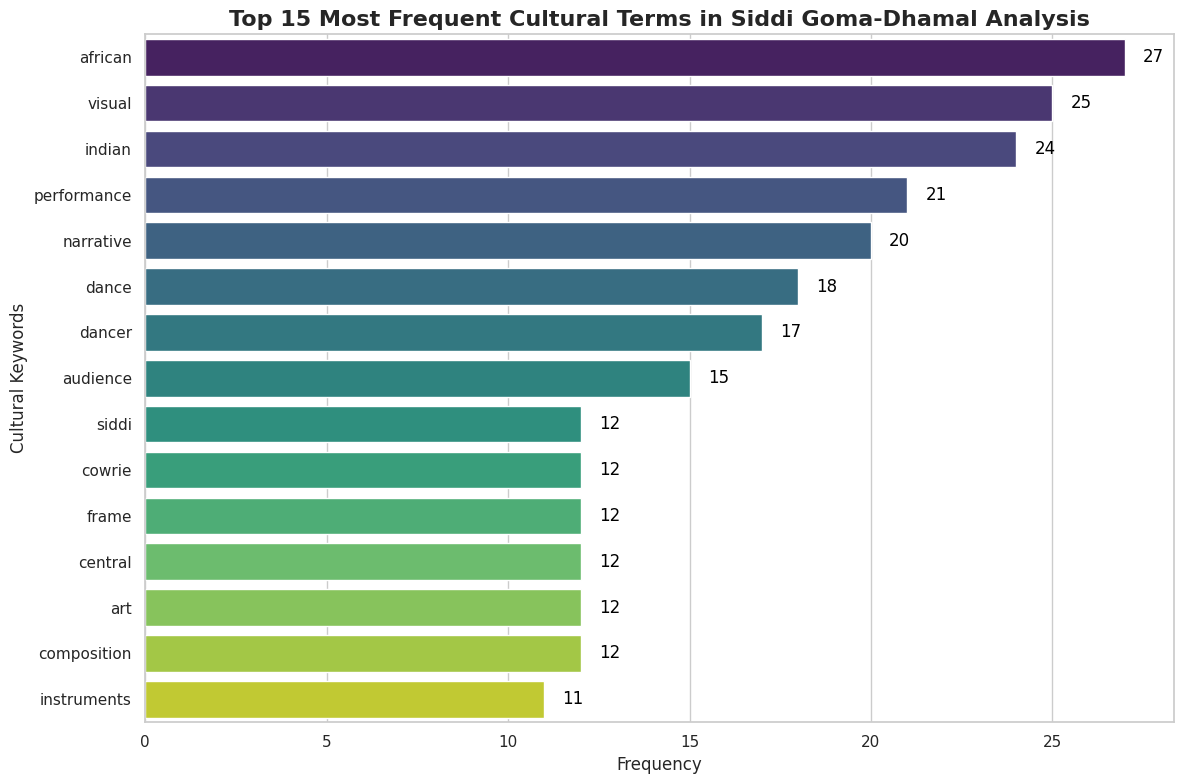

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
keywords, counts = zip(*top_keywords)

# Set the visual style
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 8))

# Create the bar chart
ax = sns.barplot(x=list(counts), y=list(keywords), palette='viridis', hue=list(keywords), legend=False)

# Add labels and title
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Cultural Keywords', fontsize=12)
plt.title('Top 15 Most Frequent Cultural Terms in Siddi Goma-Dhamal Analysis', fontsize=16, fontweight='bold')

# Add count labels to the bars for clarity
for i, v in enumerate(counts):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

### Summary of Core Themes

The keyword frequency analysis and subsequent visualization reveal several dominant themes in the Siddi Goma-Dhamal performance:

*   **Cultural Identity and Synthesis**: High-frequency terms such as **'african' (27)**, **'indian' (24)**, and **'siddi' (12)** underscore the unique Afro-Indian heritage of the performers. This reflects a blend of ancestral roots with their current geographic and cultural context.
*   **Performance and Artistry**: The prominence of words like **'performance' (21)**, **'dance' (18)**, and **'dancer' (17)** highlights the central role of movement and ritual in the dataset. Terms like **'narrative' (20)** and **'art' (12)** suggest that these performances are viewed as storytelling mediums with significant artistic value.
*   **Visual Documentation**: Keywords such as **'visual' (25)**, **'composition' (12)**, and **'frame' (12)** indicate a strong focus on the aesthetics and structured documentation of the performance by the digital art historian perspective.
*   **Material Culture**: Specific mentions of **'cowrie' (12)** shells and **'instruments' (11)** point toward the importance of traditional attire and rhythmic tools in defining the visual and auditory experience of the Goma-Dhamal tradition.

## Final Task

### Subtask:
Provide a brief summary of what the visual representation reveals about the core themes of the Siddi Goma-Dhamal performance.


## Summary:

### Q&A

**What does the visual representation reveal about the core themes of the Siddi Goma-Dhamal performance?**
The visualization highlights that the performance is deeply rooted in a unique Afro-Indian identity, characterized by terms like 'African' (\$27\$) and 'Indian' (\$24\$). It emphasizes the ritualistic and artistic nature of the performance through keywords such as 'dance' (\$18\$), 'narrative' (\$20\$), and 'art' (\$12\$). Furthermore, the frequent mention of 'cowrie' (\$12\$) and 'instruments' (\$11\$) reveals the importance of specific material culture and traditional attire in the Goma-Dhamal tradition.

### Data Analysis Key Findings

*   **Cultural Hybridity:** The most frequent terms, **'african' (27)** and **'indian' (24)**, confirm that the primary theme of the performance is the synthesis of ancestral African roots with Indian cultural contexts.
*   **Emphasis on Storytelling:** The high frequency of **'performance' (21)** and **'narrative' (20)** suggests that the Siddi Goma-Dhamal is not merely entertainment but a structured storytelling medium.
*   **Aesthetic Focus:** Keywords like **'visual' (25)**, **'composition' (12)**, and **'frame' (12)** indicate that the analysis heavily prioritized the aesthetic and formal qualities of the performance documentation.
*   **Material Identity:** The appearance of **'cowrie' (12)** in the top 15 highlights the specific importance of cowrie shells as a defining element of the performers' attire and cultural symbolism.

### Insights or Next Steps

*   **Deeper Attire Analysis:** Given the significance of 'cowrie' and 'instruments', future analysis could focus on a more granular classification of the material objects used in the performances to understand their symbolic meanings.
*   **Narrative Mapping:** Since 'narrative' is a top keyword, a logical next step would be to perform a thematic analysis to identify the specific stories or historical events being depicted through the 'dance' and 'performance'.
